# XGBoost Model Training with Optuna Optimization

This notebook builds an XGBoost model with hyperparameter tuning using Optuna and MLflow tracking.

In [17]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import os

# Add src to path - get absolute path
src_path = os.path.abspath(os.path.join(os.getcwd(), '../src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from features import FeatureEngineering
from train import TradeExceptionPredictor
from explain import ExplainabilityAnalyzer

import mlflow
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Set MLflow tracking URI
mlflow.set_tracking_uri('../mlflow_tracking')
mlflow.set_experiment('trade_exception_predictor')

<Experiment: artifact_location='file:c:/Users/Lenovo/OneDrive/Desktop/hello_world/azure-xgb/trade_exception_predictor/notebooks/../mlflow_tracking/844913239653094579', creation_time=1777204164792, experiment_id='844913239653094579', last_update_time=1777204164792, lifecycle_stage='active', name='trade_exception_predictor', tags={}, trace_location=None, workspace='default'>

In [19]:
# Load and prepare data
data_path = Path('../data/trades_synthetic.csv')
df = pd.read_csv(data_path)

# Feature engineering
fe = FeatureEngineering(df)
X, y = fe.engineer_features()

print(f"Features shape: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Features shape: (1000, 12)
Target distribution: {0: 700, 1: 300}


In [ ]:
from train import TradeExceptionPredictor                                                                                                                                          
import mlflow                                                                                                                                                                      
                                                                                                                                                                                    
# Initialize predictor                                                                                                                                                           
predictor = TradeExceptionPredictor(n_trials=2)  # Use 2 trials for quick test

print("Starting training...")
try:
    with mlflow.start_run():
        mlflow.set_tag('model_type', 'xgboost')
        predictor.train(X_train, y_train, X_test, y_test)
    print("✓ Training completed successfully!")
except Exception as e:
    print(f"✗ Error during training:")
    print(f"  Type: {type(e).__name__}")
    print(f"  Message: {str(e)}")
    import traceback
    print("\nFull traceback:")
    traceback.print_exc()

[I 2026-04-26 18:06:36,927] A new study created in memory with name: no-name-bb5d1998-ef5f-4e8c-842d-c43824a636d0


Starting training...


Best trial: 0. Best value: 0.761533:  50%|█████     | 1/2 [00:00<00:00,  4.18it/s]

[I 2026-04-26 18:06:37,165] Trial 0 finished with value: 0.761532738095238 and parameters: {'max_depth': 5, 'learning_rate': 0.07969454818643935, 'n_estimators': 800, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 0.6011150117432088}. Best is trial 0 with value: 0.761532738095238.


Best trial: 0. Best value: 0.761533: 100%|██████████| 2/2 [00:00<00:00,  2.11it/s]


[I 2026-04-26 18:06:37,872] Trial 1 finished with value: 0.7416294642857143 and parameters: {'max_depth': 8, 'learning_rate': 0.0010994335574766201, 'n_estimators': 1000, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_alpha': 0.3042422429595377, 'reg_lambda': 0.5247564316322378}. Best is trial 0 with value: 0.761532738095238.
✓ Training completed successfully!


In [21]:
y_pred = predictor.predict(X_test)
y_pred_proba = predictor.predict_proba(X_test)[:,1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Feature importance
analyzer = ExplainabilityAnalyzer(predictor.model, X_test, y_test)
importance_df = analyzer.get_feature_importance()
print("\nTop 10 Important Features:")
print(importance_df.head(10))

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.95      0.87       140
           1       0.80      0.47      0.59        60

    accuracy                           0.81       200
   macro avg       0.80      0.71      0.73       200
weighted avg       0.80      0.81      0.79       200


ROC-AUC Score: 0.7706

Top 10 Important Features:
                    feature  importance
7       price_deviation_pct    0.939063
10          speed_deviation    0.345870
3               trade_price    0.327661
4         market_volatility    0.317303
6        execution_speed_ms    0.305972
2           notional_amount    0.285676
5   counterparty_risk_score    0.272767
9           volatility_risk    0.261747
8     trade_size_percentile    0.246261
1           instrument_type    0.173497


In [22]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Train set size: 800
Test set size: 200


<Axes: xlabel='is_exception'>

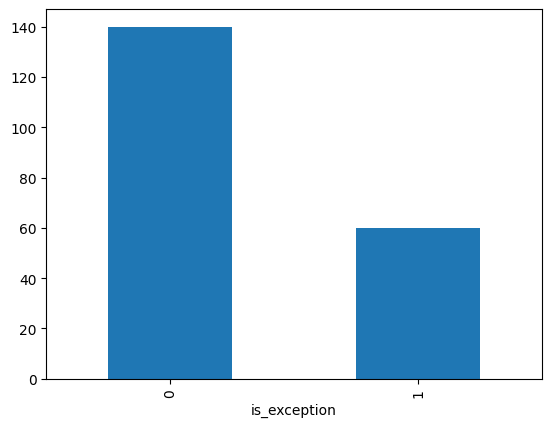

In [23]:
y_test.value_counts().plot(kind='bar')

In [24]:
# Initialize predictor with Optuna optimization
predictor = TradeExceptionPredictor(n_trials=10)

# Train model
with mlflow.start_run():
    mlflow.set_tag('model_type', 'xgboost')
    predictor.train(X_train, y_train, X_test, y_test)
    
    # Log model
    mlflow.xgboost.log_model(predictor.model, 'model')

[I 2026-04-26 18:06:38,429] A new study created in memory with name: no-name-ae99c034-c8fe-4fd9-8beb-f6c383e84fb3
Best trial: 0. Best value: 0.761533:  10%|█         | 1/10 [00:00<00:02,  3.12it/s]

[I 2026-04-26 18:06:38,749] Trial 0 finished with value: 0.761532738095238 and parameters: {'max_depth': 5, 'learning_rate': 0.07969454818643935, 'n_estimators': 800, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 0.6011150117432088}. Best is trial 0 with value: 0.761532738095238.


Best trial: 0. Best value: 0.761533:  20%|██        | 2/10 [00:01<00:04,  1.83it/s]

[I 2026-04-26 18:06:39,453] Trial 1 finished with value: 0.7416294642857143 and parameters: {'max_depth': 8, 'learning_rate': 0.0010994335574766201, 'n_estimators': 1000, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_alpha': 0.3042422429595377, 'reg_lambda': 0.5247564316322378}. Best is trial 0 with value: 0.761532738095238.


Best trial: 0. Best value: 0.761533:  30%|███       | 3/10 [00:01<00:03,  2.19it/s]

...

Best trial: 0. Best value: 0.761533:  80%|████████  | 8/10 [00:02<00:00,  5.12it/s]

[I 2026-04-26 18:06:40,347] Trial 6 finished with value: 0.7490699404761905 and parameters: {'max_depth': 7, 'learning_rate': 0.06978281265126034, 'n_estimators': 100, 'subsample': 0.5979914312095727, 'colsample_bytree': 0.522613644455269, 'min_child_weight': 4, 'gamma': 1.9433864484474102, 'reg_alpha': 0.2713490317738959, 'reg_lambda': 0.8287375091519293}. Best is trial 0 with value: 0.761532738095238.
[I 2026-04-26 18:06:40,538] Trial 7 finished with value: 0.7297247023809523 and parameters: {'max_depth': 5, 'learning_rate': 0.0036464395589807202, 'n_estimators': 600, 'subsample': 0.5704621124873813, 'colsample_bytree': 0.9010984903770198, 'min_child_weight': 1, 'gamma': 4.9344346830025865, 'reg_alpha': 0.7722447692966574, 'reg_lambda': 0.1987156815341724}. Best is trial 0 with value: 0.761532738095238.


Best trial: 0. Best value: 0.761533: 100%|██████████| 10/10 [00:02<00:00,  4.26it/s]


[I 2026-04-26 18:06:40,732] Trial 8 finished with value: 0.7529761904761906 and parameters: {'max_depth': 3, 'learning_rate': 0.04274869455295218, 'n_estimators': 800, 'subsample': 0.8645035840204937, 'colsample_bytree': 0.8856351733429728, 'min_child_weight': 1, 'gamma': 1.7923286427213632, 'reg_alpha': 0.11586905952512971, 'reg_lambda': 0.8631034258755935}. Best is trial 0 with value: 0.761532738095238.
[I 2026-04-26 18:06:40,778] Trial 9 finished with value: 0.7315848214285714 and parameters: {'max_depth': 7, 'learning_rate': 0.004589824181495649, 'n_estimators': 100, 'subsample': 0.6554911608578311, 'colsample_bytree': 0.6625916610133735, 'min_child_weight': 8, 'gamma': 3.1877873567760657, 'reg_alpha': 0.8872127425763265, 'reg_lambda': 0.4722149251619493}. Best is trial 0 with value: 0.761532738095238.


2026/04/26 18:06:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [26]:
# Evaluate model
y_pred = predictor.predict(X_test)
y_pred_proba = predictor.predict_proba(X_test)[:,1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.95      0.87       140
           1       0.80      0.47      0.59        60

    accuracy                           0.81       200
   macro avg       0.80      0.71      0.73       200
weighted avg       0.80      0.81      0.79       200


ROC-AUC Score: 0.7706


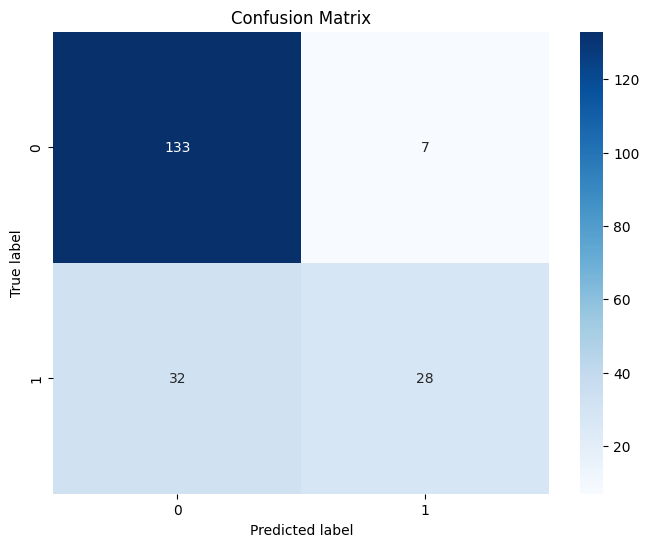

In [ ]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

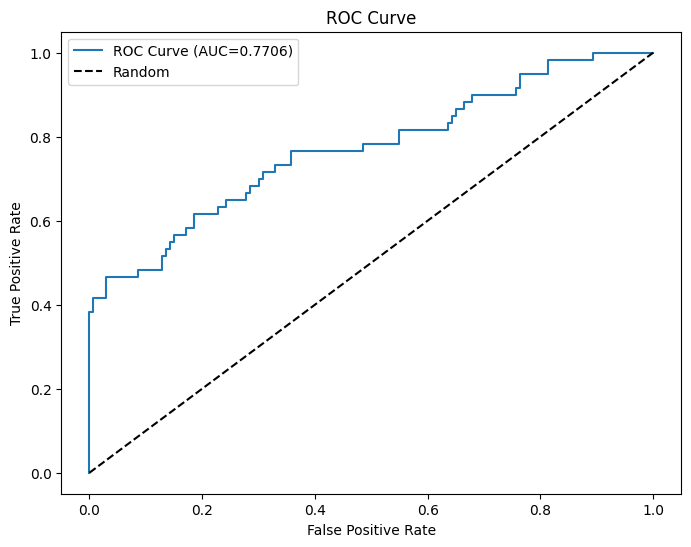

In [27]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [28]:
# Feature importance
analyzer = ExplainabilityAnalyzer(predictor.model, X_test, y_test)
importance_df = analyzer.get_feature_importance()
print("Top 10 Important Features:")
print(importance_df.head(10))

Top 10 Important Features:
                    feature  importance
7       price_deviation_pct    0.939063
10          speed_deviation    0.345870
3               trade_price    0.327661
4         market_volatility    0.317303
6        execution_speed_ms    0.305972
2           notional_amount    0.285676
5   counterparty_risk_score    0.272767
9           volatility_risk    0.261747
8     trade_size_percentile    0.246261
1           instrument_type    0.173497


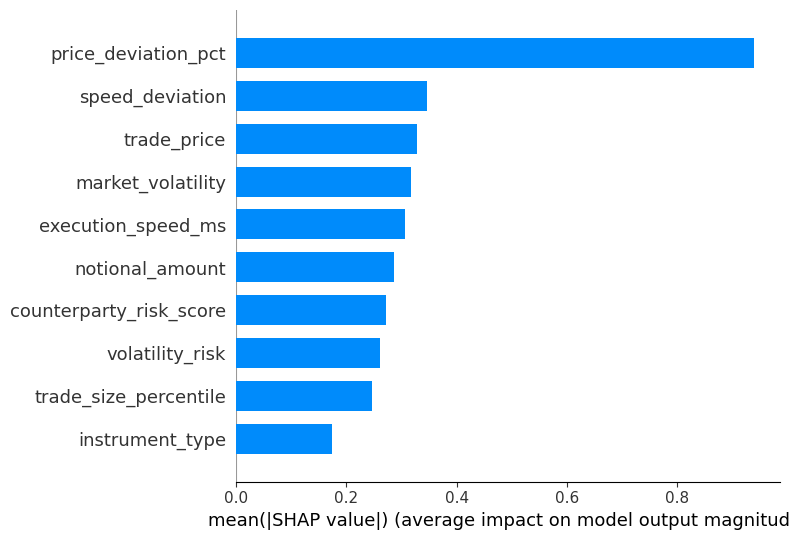

<Figure size 1000x600 with 0 Axes>

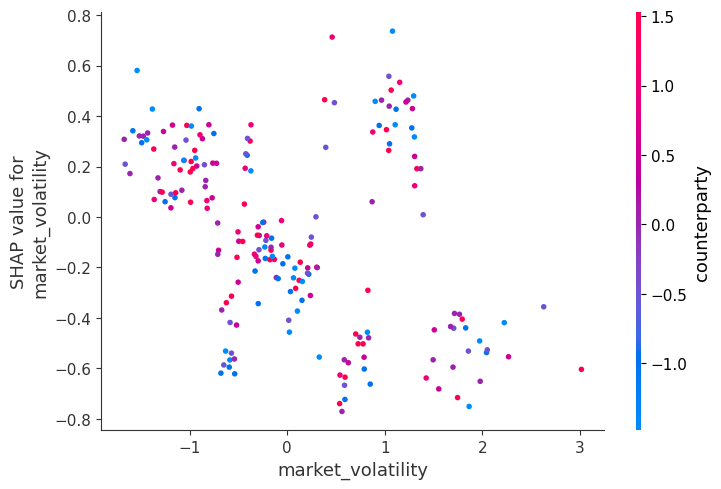

In [29]:
# SHAP analysis
analyzer.plot_shap_summary()
analyzer.plot_shap_dependence('market_volatility')